In [1]:
import Metrica_IO as mio
import Metrica_Viz as mviz
import Metrica_Velocities as mvel
import Metrica_PitchControl as mpc
import Metrica_EPV as mepv


In [2]:
DATADIR = "data"

game_id = 2

# read in the event data
events = mio.read_event_data(DATADIR, game_id)

# read in tracking data
tracking_home = mio.tracking_data(DATADIR, game_id, "Home")
tracking_away = mio.tracking_data(DATADIR, game_id, "Away")

# Convert positions from metrica units to meters (note change in Metrica's coordinate system since the last lesson)
tracking_home = mio.to_metric_coordinates(tracking_home)
tracking_away = mio.to_metric_coordinates(tracking_away)
events = mio.to_metric_coordinates(events)

Reading team: home
Reading team: away


In [3]:
# reverse direction of play in the second half so that home team is always attacking from right->left
tracking_home, tracking_away, events = mio.to_single_playing_direction(
    tracking_home, tracking_away, events
)


In [4]:
# Calculate player velocities
tracking_home = mvel.calc_player_velocities(tracking_home, smoothing=True)
tracking_away = mvel.calc_player_velocities(tracking_away, smoothing=True)


d:\HEC Paris\M2\Personal Project\football-tactical-analysis\Metrica_Velocities.py:53: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dt = team["Time [s]"].diff().fillna(method="bfill")  # Fill first row
d:\HEC Paris\M2\Personal Project\football-tactical-analysis\Metrica_Velocities.py:53: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dt = team["Time [s]"].diff().fillna(method="bfill")  # Fill first row


In [5]:
# first get pitch control model parameters
params = mpc.default_model_params()
# find goalkeepers for offside calculation
GK_numbers = [mio.find_goalkeeper(tracking_home), mio.find_goalkeeper(tracking_away)]


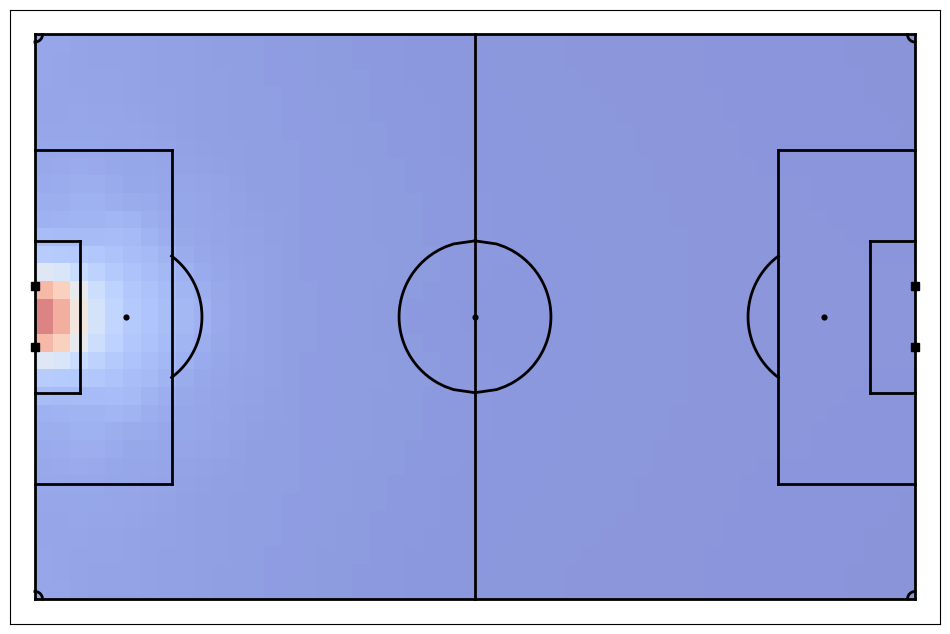

In [6]:
""" *** GET EPV SURFACE **** """
home_attack_direction = mio.find_playing_direction(
    tracking_home, "Home"
)  # 1 if shooting left-right, else -1
EPV = mepv.load_EPV_grid(DATADIR + "/EPV_grid.csv")
# plot the EPV surface
mviz.plot_EPV(EPV, field_dimen=(106.0, 68), attack_direction=home_attack_direction)


(<Figure size 1200x800 with 1 Axes>, <Axes: >)

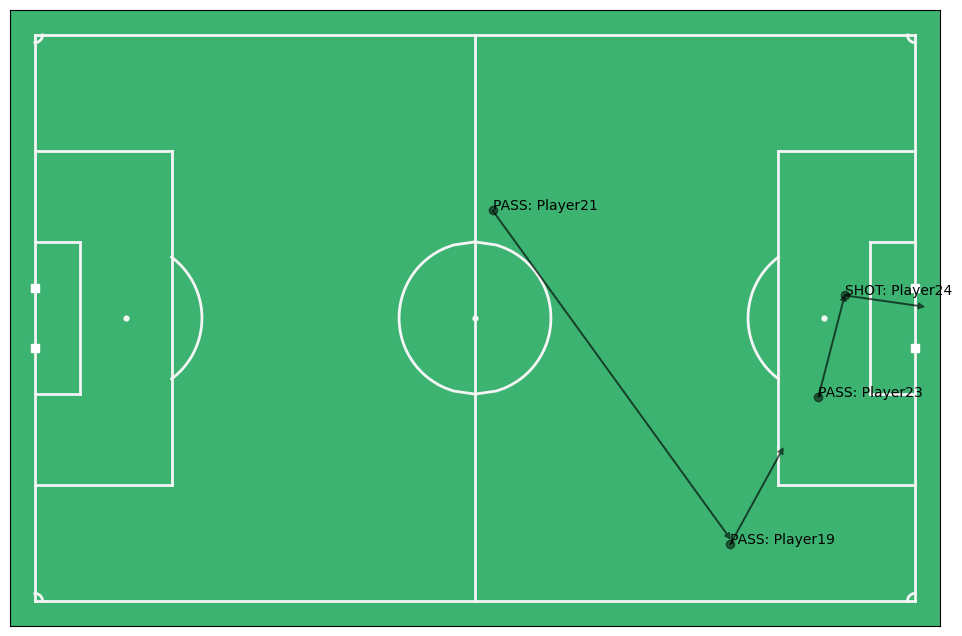

In [7]:
# plot event leading up to first away team goal
mviz.plot_events(
    events.loc[820:823], color="k", indicators=["Marker", "Arrow"], annotate=True
)


(<Figure size 1200x800 with 1 Axes>, <Axes: >)

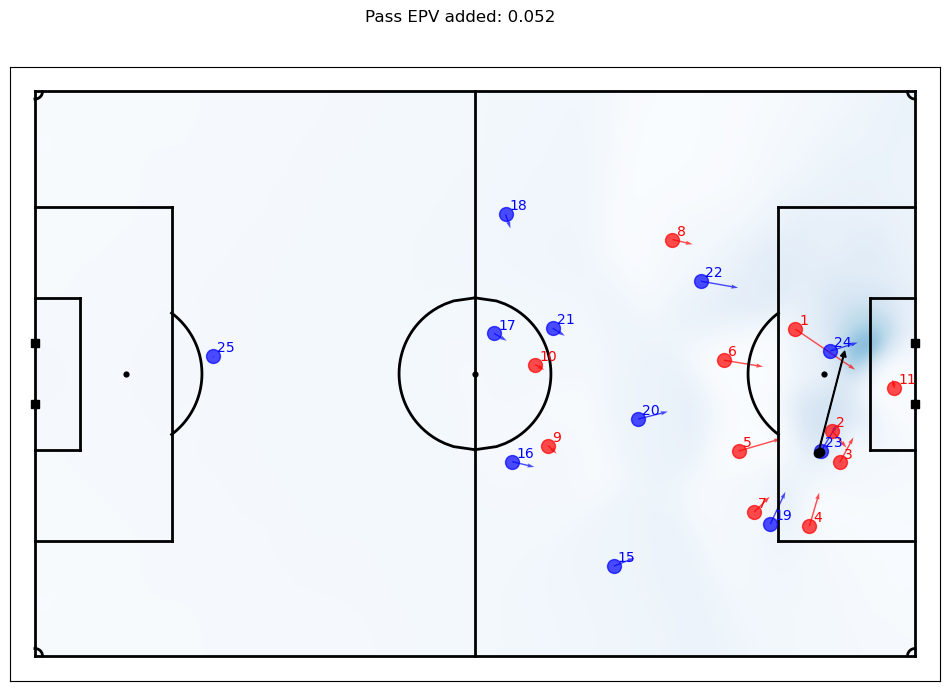

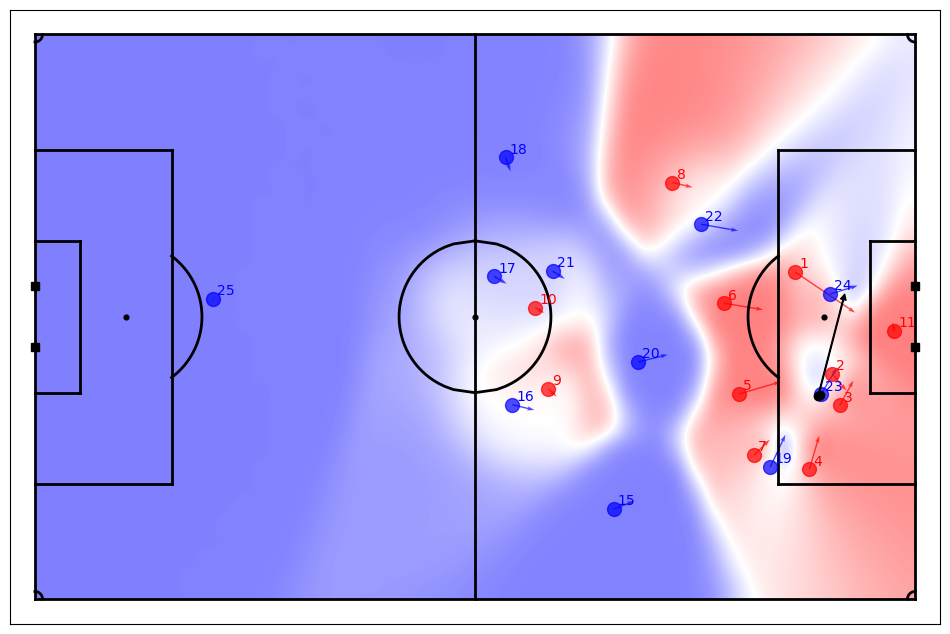

In [8]:
# Calculate value-added for assist and plot expected value surface
event_number = 822  # away team first goal
EEPV_added, EPV_diff = mepv.calculate_epv_added(
    event_number, events, tracking_home, tracking_away, GK_numbers, EPV, params
)
PPCF, xgrid, ygrid = mpc.generate_pitch_control_for_event(
    event_number,
    events,
    tracking_home,
    tracking_away,
    params,
    GK_numbers,
    field_dimen=(
        106.0,
        68.0,
    ),
    n_grid_cells_x=50,
    offsides=True,
)
fig, ax = mviz.plot_EPV_for_event(
    event_number,
    events,
    tracking_home,
    tracking_away,
    PPCF,
    EPV,
    annotate=True,
    autoscale=True,
)
fig.suptitle("Pass EPV added: %1.3f" % EEPV_added, y=0.95)
mviz.plot_pitchcontrol_for_event(
    event_number, events, tracking_home, tracking_away, PPCF, annotate=True
)


In [9]:
""" **** calculate value-added for all passes **** """

# first get all shots
shots = events[events["Type"] == "SHOT"]
home_shots = shots[shots["Team"] == "Home"]
away_shots = shots[shots["Team"] == "Away"]
# get all  passes
home_passes = events[(events["Type"].isin(["PASS"])) & (events["Team"] == "Home")]
away_passes = events[(events["Type"].isin(["PASS"])) & (events["Team"] == "Away")]

# home team value added
home_pass_value_added = []
for i, pass_ in home_passes.iterrows():
    EEPV_added, EPV_diff = mepv.calculate_epv_added(
        i, events, tracking_home, tracking_away, GK_numbers, EPV, params
    )
    home_pass_value_added.append((i, EEPV_added, EPV_diff))

# away team value added
away_pass_value_added = []
for i, pass_ in away_passes.iterrows():
    EEPV_added, EPV_diff = mepv.calculate_epv_added(
        i, events, tracking_home, tracking_away, GK_numbers, EPV, params
    )
    away_pass_value_added.append((i, EEPV_added, EPV_diff))


home_pass_value_added = sorted(home_pass_value_added, key=lambda x: x[1], reverse=True)
away_pass_value_added = sorted(away_pass_value_added, key=lambda x: x[1], reverse=True)

print("Top 5 home team passes by expected EPV-added")
print(home_pass_value_added[:5])
print("Top 5 away team passes by expected EPV-added")
print(away_pass_value_added[:5])


Top 5 home team passes by expected EPV-added
[(1753, np.float64(0.09304278802164595), np.float64(0.2252)), (1478, np.float64(0.08235703576922077), np.float64(0.36379999999999996)), (197, np.float64(0.06266328336978927), np.float64(0.2444)), (430, np.float64(0.04834837878931096), np.float64(0.10749999999999998)), (851, np.float64(0.044903118708377196), np.float64(0.1001))]
Top 5 away team passes by expected EPV-added
[(1663, np.float64(0.07283823310739937), np.float64(0.0378)), (961, np.float64(0.07003881694848728), np.float64(0.1555)), (1901, np.float64(0.06456906587620756), np.float64(0.2474)), (822, np.float64(0.0516305593389679), np.float64(0.0664)), (1735, np.float64(0.0318064308228498), np.float64(-0.005600000000000001))]


(<Figure size 1200x800 with 1 Axes>, <Axes: >)

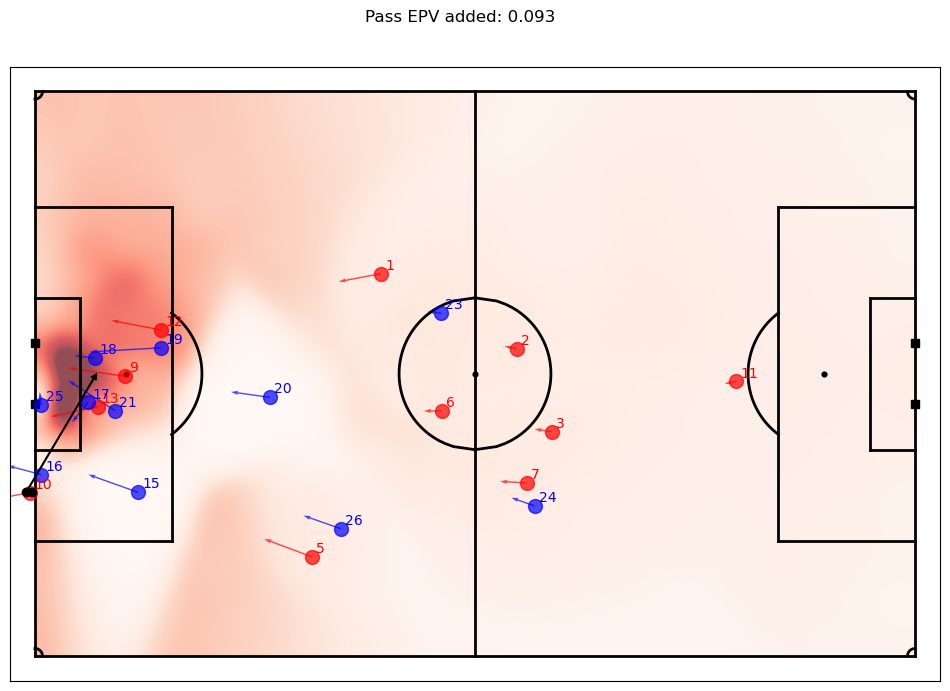

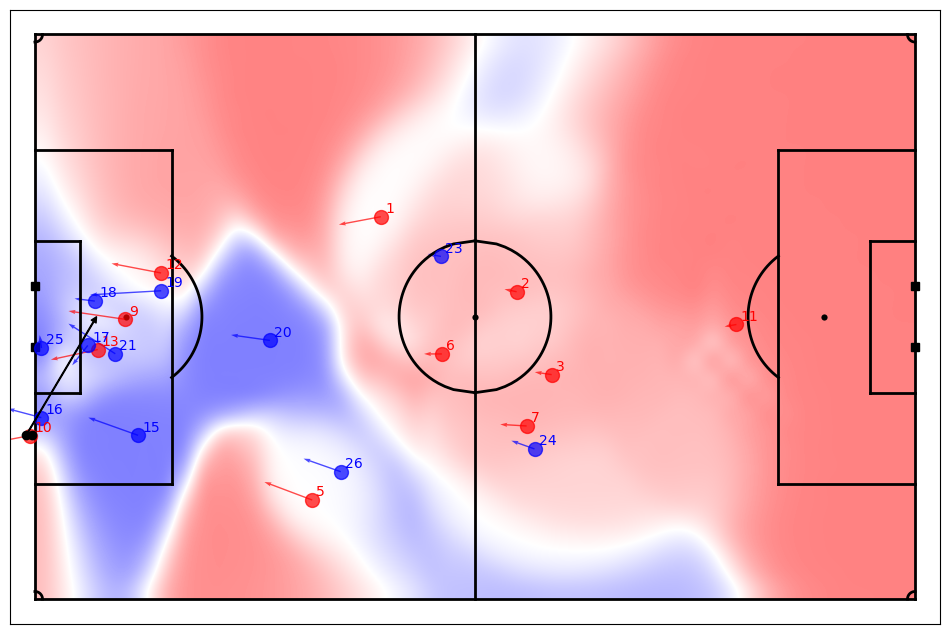

In [10]:
event_number = 1753  # home team assist to header off target
EEPV_added, EPV_diff = mepv.calculate_epv_added(
    event_number, events, tracking_home, tracking_away, GK_numbers, EPV, params
)
PPCF, xgrid, ygrid = mpc.generate_pitch_control_for_event(
    event_number,
    events,
    tracking_home,
    tracking_away,
    params,
    GK_numbers,
    field_dimen=(
        106.0,
        68.0,
    ),
    n_grid_cells_x=50,
    offsides=True,
)
fig, ax = mviz.plot_EPV_for_event(
    event_number, events, tracking_home, tracking_away, PPCF, EPV, annotate=True
)
fig.suptitle("Pass EPV added: %1.3f" % EEPV_added, y=0.95)
mviz.plot_pitchcontrol_for_event(
    event_number, events, tracking_home, tracking_away, PPCF, annotate=True
)


(<Figure size 1200x800 with 1 Axes>, <Axes: >)

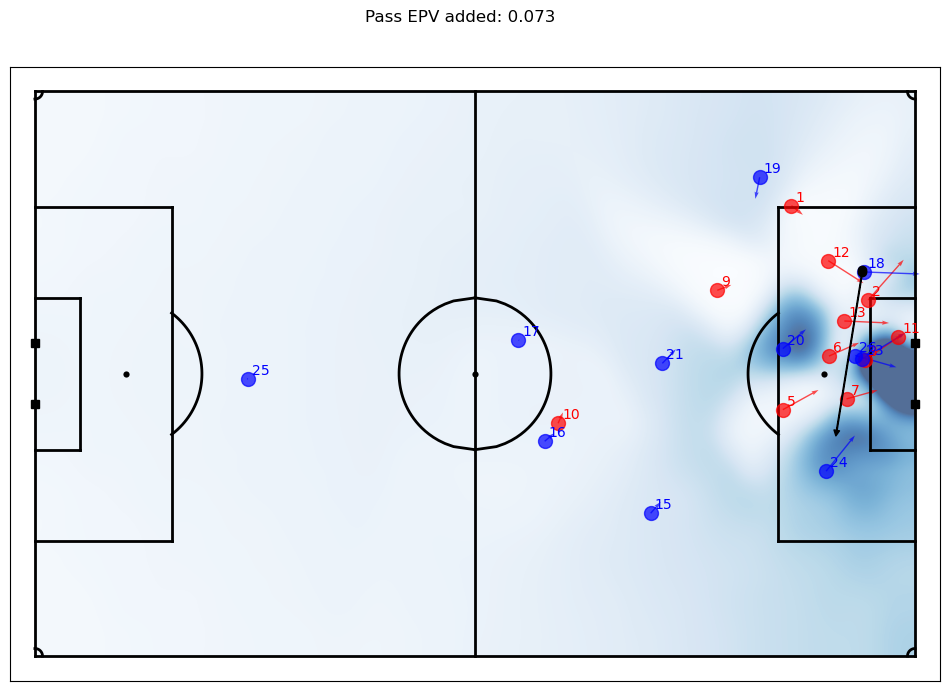

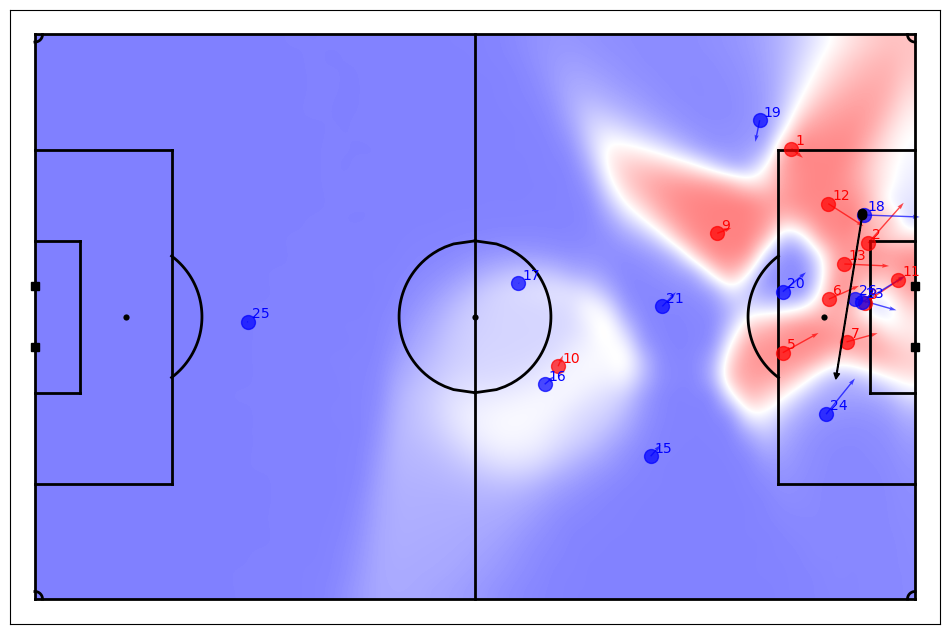

In [11]:
event_number = 1663  # away team assisst to blocked shot
EEPV_added, EPV_diff = mepv.calculate_epv_added(
    event_number, events, tracking_home, tracking_away, GK_numbers, EPV, params
)
PPCF, xgrid, ygrid = mpc.generate_pitch_control_for_event(
    event_number,
    events,
    tracking_home,
    tracking_away,
    params,
    GK_numbers,
    field_dimen=(
        106.0,
        68.0,
    ),
    n_grid_cells_x=50,
    offsides=True,
)
fig, ax = mviz.plot_EPV_for_event(
    event_number, events, tracking_home, tracking_away, PPCF, EPV, annotate=True
)
fig.suptitle("Pass EPV added: %1.3f" % EEPV_added, y=0.95)
mviz.plot_pitchcontrol_for_event(
    event_number, events, tracking_home, tracking_away, PPCF, annotate=True
)


(<Figure size 1200x800 with 1 Axes>, <Axes: >)

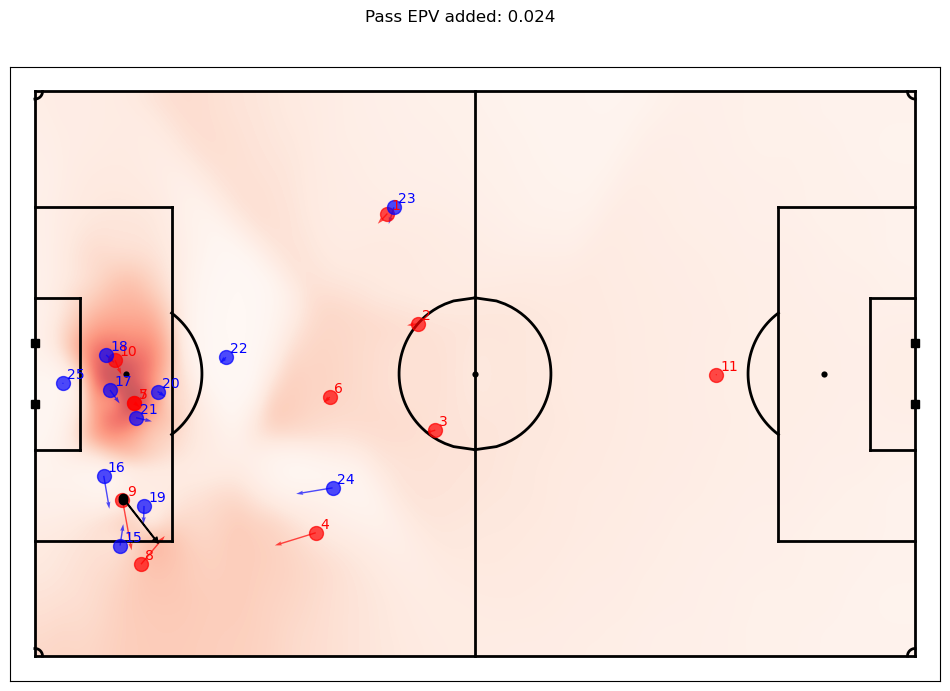

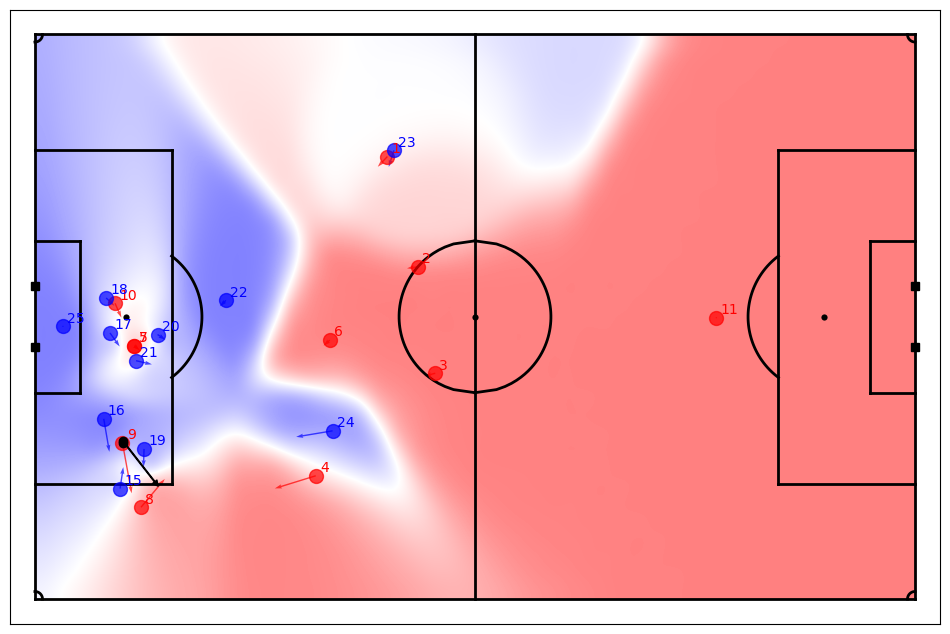

In [12]:
# retaining possession
event_number = 195
EEPV_added, EPV_diff = mepv.calculate_epv_added(
    event_number, events, tracking_home, tracking_away, GK_numbers, EPV, params
)
PPCF, xgrid, ygrid = mpc.generate_pitch_control_for_event(
    event_number,
    events,
    tracking_home,
    tracking_away,
    params,
    GK_numbers,
    field_dimen=(
        106.0,
        68.0,
    ),
    n_grid_cells_x=50,
    offsides=True,
)
fig, ax = mviz.plot_EPV_for_event(
    event_number, events, tracking_home, tracking_away, PPCF, EPV, annotate=True
)
fig.suptitle("Pass EPV added: %1.3f" % EEPV_added, y=0.95)
mviz.plot_pitchcontrol_for_event(
    event_number, events, tracking_home, tracking_away, PPCF, annotate=True
)


In [13]:
# # find maximum possible EPV-added for all home team passes (takes a while to run!)
# maximum_EPV_added = []
# for i, row in home_passes.iterrows():
#     print("Event %d" % (i))
#     EEPV_added, EPV_diff = mepv.calculate_epv_added(
#         i, events, tracking_home, tracking_away, GK_numbers, EPV, params
#     )
#     max_EEPV_added, target = mepv.find_max_value_added_target(
#         i, events, tracking_home, tracking_away, GK_numbers, EPV, params
#     )
#     maximum_EPV_added.append((i, max_EEPV_added, EEPV_added, EPV_diff))

# # sort by the difference between maximum value-added and value-added for the actual pass that was made
# # note: some values may be slightly negative because of how the maximum value-added search is performed over a grid
# maximum_EPV_added = sorted(maximum_EPV_added, key=lambda x: x[1] - x[2], reverse=True)


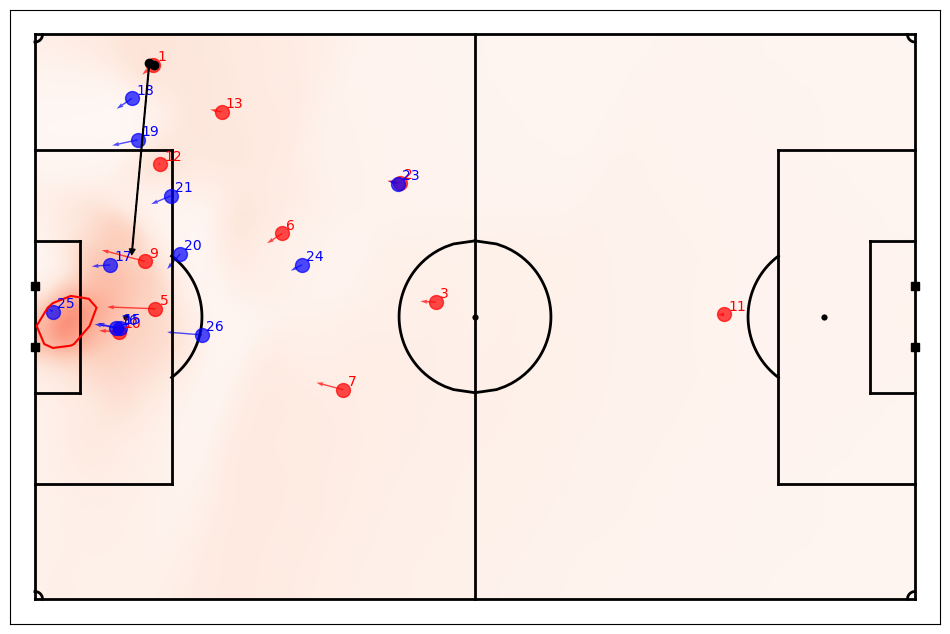

In [14]:
# assist example
event_number = 1680
PPCF, xgrid, ygrid = mpc.generate_pitch_control_for_event(
    event_number,
    events,
    tracking_home,
    tracking_away,
    params,
    GK_numbers,
    field_dimen=(
        106.0,
        68.0,
    ),
    n_grid_cells_x=50,
    offsides=True,
)
fig, ax = mviz.plot_EPV_for_event(
    event_number,
    events,
    tracking_home,
    tracking_away,
    PPCF,
    EPV,
    annotate=True,
    autoscale=True,
    contours=True,
)


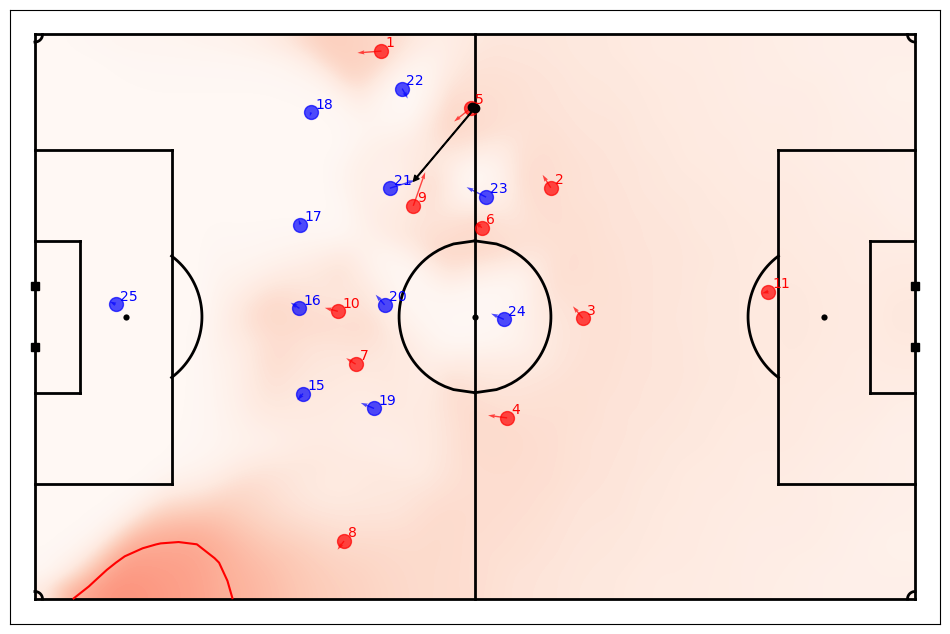

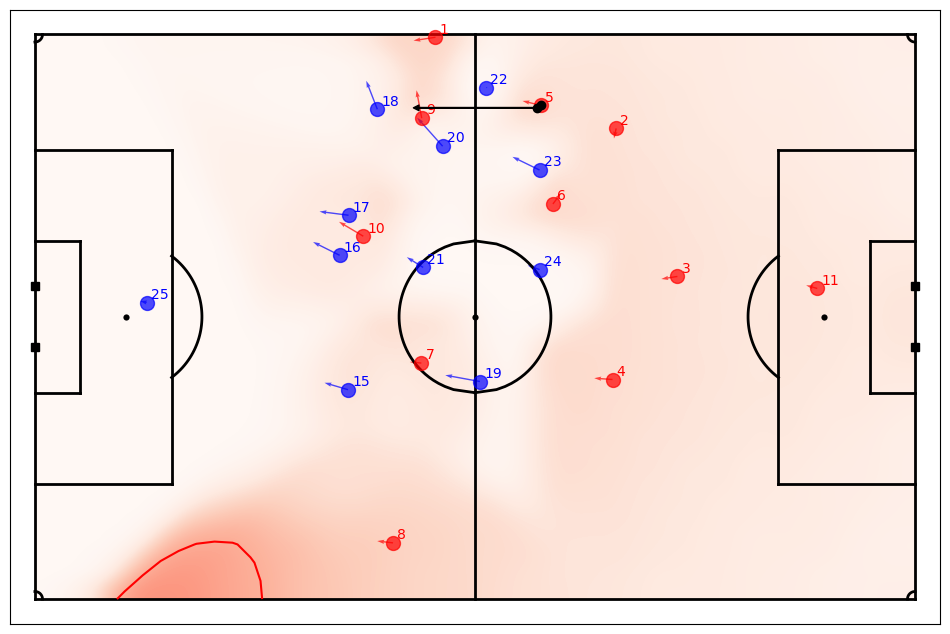

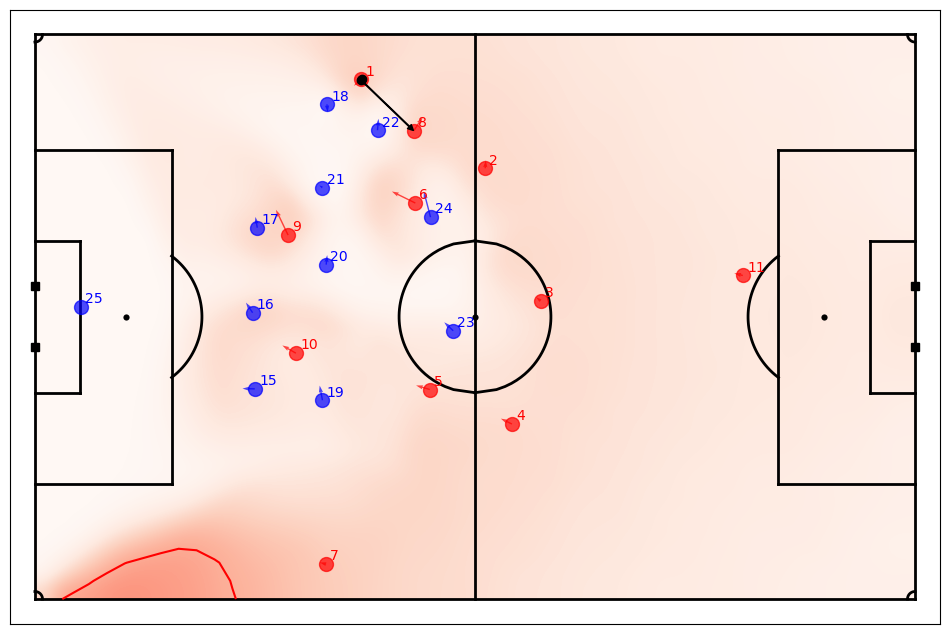

In [15]:
# cross-field passes
examples = [403, 68, 829]
for event_number in examples:
    PPCF, xgrid, ygrid = mpc.generate_pitch_control_for_event(
        event_number,
        events,
        tracking_home,
        tracking_away,
        params,
        GK_numbers,
        field_dimen=(
            106.0,
            68.0,
        ),
        n_grid_cells_x=50,
        offsides=True,
    )
    fig, ax = mviz.plot_EPV_for_event(
        event_number,
        events,
        tracking_home,
        tracking_away,
        PPCF,
        EPV,
        annotate=True,
        autoscale=True,
        contours=True,
    )
